<center>
<a href="http://www.insa-toulouse.fr/" ><img src="http://www.math.univ-toulouse.fr/~besse/Wikistat/Images/logo-insa.jpg" style="float:left; max-width: 120px; display: inline" alt="INSA"/></a> 

</center>

# Projet Machine Learning — 4MA 2025-2026
## Prédiction du Risque de Maladie Cardiovasculaire
### INSA Toulouse
---

**Jeu de données** : *Cardiovascular Disease Risk Prediction Dataset* : 15 000 patients   
**Langage** : Python   
**Objectifs** :
- Partie 1 : Prédiction de `Heart_Disease_Risk` 
- Partie 2 : Prédiction de `Cholesterol_LDL` 

> Ce notebook vient compléter l'étude réalisée en R. Les conclusions sont comparables, > mais Python offre une exécution plus rapide, notamment pour la validation croisée.

### 0. Importation des bibliothèques et chargement des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

randomseed = 111 

In [2]:
df = pd.read_csv("healthcare_synthetic_data.csv")
print(df.shape)
df.head()


(15000, 19)


,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
0,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
1,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
2,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
3,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
4,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0


In [3]:
# Vérification des types de données et des valeurs manquantes
print("Types des variables :")
print(df.dtypes)
print("\nValeurs manquantes :")
print(df.isnull().sum())

# Prétraitement des données
df = df.drop(columns=["Patient_ID"])
for col in ["Gender", "Smoking_Status", "Family_History", "Heart_Disease_Risk"]:
    df[col] = pd.Categorical(df[col], ordered=False)
df["Alcohol_Consumption"] = pd.Categorical(
    df["Alcohol_Consumption"], categories=[0, 1, 2], ordered=True)
df["Physical_Activity_Level"] = pd.Categorical(
    df["Physical_Activity_Level"], categories=[0, 1, 2, 3], ordered=True)
print(df.dtypes)
df.describe()


Types des variables :
Patient_ID                     str
Age                          int64
Gender                       int64
Height_cm                  float64
Weight_kg                  float64
BMI                        float64
Systolic_BP                  int64
Diastolic_BP                 int64
Cholesterol_Total            int64
Cholesterol_LDL              int64
Cholesterol_HDL              int64
Fasting_Blood_Sugar          int64
Smoking_Status               int64
Alcohol_Consumption          int64
Physical_Activity_Level      int64
Family_History               int64
Stress_Level                 int64
Sleep_Hours                  int64
Heart_Disease_Risk           int64
dtype: object

Valeurs manquantes :
Patient_ID                 0
Age                        0
Gender                     0
Height_cm                  0
Weight_kg                  0
BMI                        0
Systolic_BP                0
Diastolic_BP               0
Cholesterol_Total          0
Cholesterol_LDL 

,Age,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Stress_Level,Sleep_Hours
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,54.538133,165.336767,75.252573,27.446080,135.117667,90.541267,216.248000,140.355267,43.307867,99.670200,5.503667,6.506067
std,11.875294,9.186313,14.110559,4.134953,11.260634,8.443095,22.692222,17.914089,5.963153,15.261355,2.874277,1.212626
min,25.000000,138.500000,33.700000,14.500000,90.000000,60.000000,127.000000,70.000000,20.000000,60.000000,1.000000,4.000000
25%,46.000000,158.500000,65.200000,24.500000,127.000000,85.000000,201.000000,128.000000,39.000000,89.000000,3.000000,6.000000
50%,55.000000,164.700000,73.900000,27.200000,135.000000,91.000000,216.000000,140.000000,43.000000,99.000000,5.500000,7.000000
75%,63.000000,172.000000,83.900000,30.000000,143.000000,96.000000,231.000000,152.000000,47.000000,110.000000,8.000000,7.000000
max,85.000000,198.100000,150.100000,46.100000,182.000000,120.000000,303.000000,210.000000,68.000000,167.000000,10.000000,10.000000


### 1. Prédiction du risque d’accident cardiaque

In [4]:
X = df.drop(columns=["Heart_Disease_Risk"])
y = df["Heart_Disease_Risk"]

In [5]:

# Division en ensembles d'apprentissage et de test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=randomseed)

# Vérification des tailles des ensembles
print("Taille apprentissage :", X_train.shape[0])
print("Taille test :", X_test.shape[0])

# Normalisation
scaler = StandardScaler()
scaler.fit(X_train)
Xr_train = scaler.transform(X_train)
Xr_test = scaler.transform(X_test)



Taille apprentissage : 12000
Taille test : 3000


Cette étape est essentielle car elle permet d'estimer les performances réelles du modèle sur des données qu'il n'a jamais vues durant l'apprentissage. Sans cette séparation, le modèle pourrait simplement mémoriser les données d'entraînement et afficher de bonnes performances sans pour autant être capable de généraliser à de nouveaux patients.On retient 20% des données pour le test, soit 3 000 patients.

#### 1.1 Modèle Linéaire Généralisé

##### 1.1.1 Sans pénalisation et sans séléction des variables 

Commentaire pour expliquer que dans ce cas on va pas faire la selection des variables ...

c:\Users\Dr console\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Accuracy Train : 0.7361
Accuracy Test  : 0.7530

Matrice de confusion (Test) :
[[1426  335]
 [ 406  833]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.78      0.81      0.79      1761
           1       0.71      0.67      0.69      1239

    accuracy                           0.75      3000
   macro avg       0.75      0.74      0.74      3000
weighted avg       0.75      0.75      0.75      3000



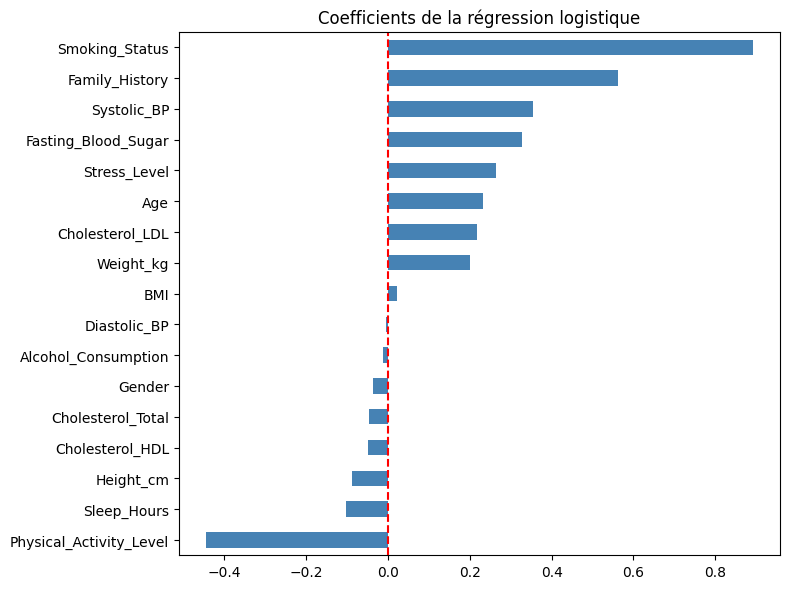

In [25]:
# Visualisation des oefficients
coef = pd.Series(ModelLin.coef_[0], index=X.columns)
print(f"Variables éliminées : {sum(coef == 0)}")
coef.sort_values().plot(kind='barh', figsize=(8,6), color='teal')
plt.title("Coefficients - Régression Logistique sans pénalisation")
plt.axvline(0, color='powderblue', linestyle='--')
plt.tight_layout()
plt.show()

##### 1.1.2 Pénalisation LASSO L1 

c:\Users\Dr console\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\Dr console\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\Dr console\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplifi

C optimal : 21.5443
Accuracy Train : 0.7361
Accuracy Test  : 0.7530

Matrice de confusion (Test) :
[[1426  335]
 [ 406  833]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.78      0.81      0.79      1761
           1       0.71      0.67      0.69      1239

    accuracy                           0.75      3000
   macro avg       0.75      0.74      0.74      3000
weighted avg       0.75      0.75      0.75      3000


Variables éliminées (coef = 0) : 0
Variables conservées : 17


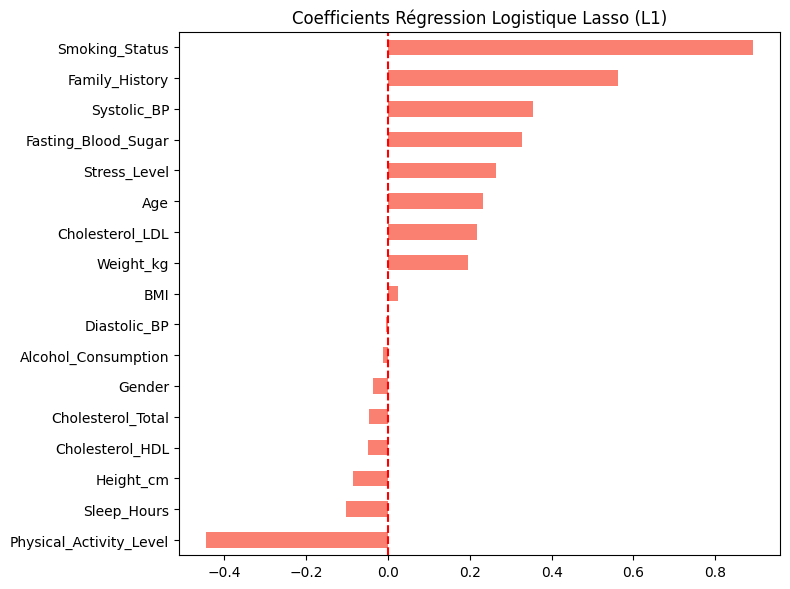

In [26]:
# Visualisation des coefficients
coef_lasso = pd.Series(logit0pt.best_estimator_.coef_[0], index=X.columns)
print(f"Variables éliminées : {sum(coef_lasso == 0)}")
coef_lasso.sort_values().plot(kind='barh', figsize=(8,6), color='salmon')
plt.title("Coefficients - Régression Logistique Lasso (L1)")
plt.axvline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

Avec le C optimal trouvé par validation croisée, le Lasso ne met aucun coefficient à zéro. Les résultats avec pénalisation Lasso (C optimal) sont proches de celles sans pénalisation. Pour un peu pousser l'effet de Lasso sur notre modèle on teste différente valeur de C et voir les variables qui on étés supprimées au bout d'un moment

In [27]:
# ── Régression Logistique avec pénalisation L2 ────────────────
# L2 est le penalty par défaut de LogisticRegressionCV
log_ridge = LogisticRegressionCV(
    penalty='l2',
    solver='saga',
    cv=10,
    max_iter=1000,
    random_state=randomseed
)
log_ridge.fit(X_train_scaled, y_train)

# ── C optimal trouvé par validation croisée ───────────────────
print(f"C optimal : {log_ridge.C_[0]:.4f}")

# ── Prédictions ───────────────────────────────────────────────
y_pred_train_ridge = log_ridge.predict(X_train_scaled)
y_pred_test_ridge  = log_ridge.predict(X_test_scaled)

# ── Performances ──────────────────────────────────────────────
print(f"Accuracy Train : {accuracy_score(y_train, y_pred_train_ridge):.4f}")
print(f"Accuracy Test  : {accuracy_score(y_test, y_pred_test_ridge):.4f}")
print("\nMatrice de confusion (Test) :")
print(confusion_matrix(y_test, y_pred_test_ridge))
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_test_ridge))

# ── Coefficients ────────────────

In [28]:
# ── Tableau comparatif des 3 modèles ─────────────────────────
resultats_logit = pd.DataFrame({
    "Modèle": [
        "Logistique (sans pénalisation)",
        "Logistique Lasso (L1)",
        "Logistique Ridge (L2)"
    ],
    "C optimal": ["-", "21.5443", "2.7826"],
    "Accuracy Train": [0.7361, 0.7361, 0.7361],
    "Accuracy Test":  [0.7530, 0.7530, 0.7530],
    "F1-score (classe 1)": [0.69, 0.69, 0.69],
    "Variables éliminées": ["-", "0", "-"]
})

print(resultats_logit.to_string(index=False))

                        Modèle C optimal  Accuracy Train  Accuracy Test  F1-score (classe 1) Variables éliminées
Logistique (sans pénalisation)         -          0.7361          0.753                 0.69                   -
         Logistique Lasso (L1)   21.5443          0.7361          0.753                 0.69                   0
         Logistique Ridge (L2)    2.7826          0.7361          0.753                 0.69                   -


#### 1.2 Support Vector Machine (SVM)

Dans cette partie, nous appliquons la méthode des Support Vector Machines pour la classification de la variable *Heart_Disease_Risk*. 

Nous commençons par un modèle SVM avec noyau linéaire, puis un noyau gaussien (RBF). 
Enfin, nous optimisons les hyperparamètres du modèle par validation croisée afin d’améliorer ses performances.

##### 1.2.1 SVM linéaire

In [ ]:
from sklearn.svm import SVC

ts = time.time()

svm_linear = SVC(kernel='linear', random_state=randomseed)
svm_linear.fit(X_train_scaled, y_train)

score_linear = svm_linear.score(X_test_scaled, y_test)
y_pred_linear = svm_linear.predict(X_test_scaled)

te = time.time()

In [ ]:
print("Score SVM linéaire : %f, Temps : %f secondes" % (score_linear, te - ts))

pd.DataFrame(confusion_matrix(y_test, y_pred_linear),
             index=["0 réel","1 réel"],
             columns=["0 prédit","1 prédit"])

Le modèle SVM linéaire obtient une accuracy d’environ **0.745**, ce qui constitue une performance correcte.

La matrice de confusion montre que :
- Le modèle prédit relativement bien les individus à faible risque (classe 0)
- Cependant, il commet encore un nombre non négligeable d’erreurs sur la classe 1 (risque élevé)

Cela suggère que la relation entre les variables explicatives et la variable cible n’est pas strictement linéaire.

##### 1.2.2 SVM avec noyau gaussien (RBF)

In [ ]:
ts = time.time()

svm_rbf = SVC(kernel='rbf', gamma='auto', random_state=randomseed)
svm_rbf.fit(X_train_scaled, y_train)

score_rbf = svm_rbf.score(X_test_scaled, y_test)
y_pred_rbf = svm_rbf.predict(X_test_scaled)

te = time.time()

In [ ]:
print("Score SVM RBF : %f, Temps : %f secondes" % (score_rbf, te - ts))

pd.DataFrame(confusion_matrix(y_test, y_pred_rbf),
             index=["0 réel","1 réel"],
             columns=["0 prédit","1 prédit"])

Le modèle SVM avec noyau gaussien (RBF) obtient une accuracy d’environ **0.743**, très proche de celle du modèle linéaire.

La matrice de confusion montre une répartition des erreurs similaire au modèle linéaire, avec :
- Une bonne détection de la classe 0
- Des difficultés persistantes sur la classe 1

Le noyau RBF, plus flexible, n’apporte pas ici d’amélioration significative, ce qui peut indiquer que les relations dans les données ne sont pas fortement non linéaires ou que les paramètres ne sont pas encore optimisés.

##### Comparaison SVM linéaire vs RBF

Les deux modèles donnent des performances très proches.  
Le noyau RBF n’apporte pas d’amélioration notable par rapport au modèle linéaire dans cette configuration.

##### 1.2.3 Optimisation des hyperparamètres 

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC

ts = time.time()

param_dist = {
    "C": np.logspace(-2, 2, 10),      # valeurs entre 0.01 et 100
    "gamma": np.logspace(-3, 1, 10)   # valeurs entre 0.001 et 10
}

svm_random = RandomizedSearchCV(
    SVC(kernel='rbf'),
    param_distributions=param_dist,
    n_iter=10,        # nombre de tests (petit = rapide)
    cv=3,             # validation croisée
    n_jobs=-1,
    random_state=randomseed
)

svmOpt = svm_random.fit(X_train_scaled, y_train)

te = time.time()

In [ ]:
print("Meilleur score : %f" % svmOpt.best_score_)
print("Meilleurs paramètres :", svmOpt.best_params_)
print("Temps optimisation :", te - ts)

In [ ]:
best_svm = svmOpt.best_estimator_

score_opt = best_svm.score(X_test_scaled, y_test)
y_pred_opt = best_svm.predict(X_test_scaled)

print("Score SVM optimisé :", score_opt)

pd.DataFrame(confusion_matrix(y_test, y_pred_opt),
             index=["0 réel","1 réel"],
             columns=["0 prédit","1 prédit"])

Après optimisation des hyperparamètres avec RandomizedSearchCV, le modèle obtient une accuracy d’environ **0.743**, proche des modèles précédents.

Les paramètres optimaux trouvés (C ≈ 0.6, gamma ≈ 0.06) indiquent un compromis entre complexité du modèle et régularisation.

La matrice de confusion montre que :
- Le modèle reste performant pour prédire la classe 0 (faible risque)
- Les erreurs sur la classe 1 (risque élevé) persistent, ce qui indique une difficulté à détecter correctement les cas à risque

L’optimisation n’apporte pas d’amélioration significative, ce qui suggère que les performances du SVM sont limitées sur ce jeu de données.

#### Régression Linéaire sur la variable Cholestérol

On s'intéresse maintenant à la prédiction de la variable quantitative `Cholesterol_LDL` 
(mauvais cholestérol) à partir de toutes les variables **sauf** `Heart_Disease_Risk`.

Contrairement à la partie 1 (classification), il s'agit ici d'un problème de **régression** :
la variable cible est une variable quantitative. On utilise le modèle linéaire comme base de référence,
évalué par le **MSE** et le **R²**.

##### Récupération et entrainnement des données

In [47]:
X_chol = df.drop(columns=["Heart_Disease_Risk","Cholesterol_HDL"])
Y_chol = df["Cholesterol_HDL"]

In [48]:
X_train_chol, X_test_chol, y_train_chol, y_test_chol = train_test_split(
    X, y, test_size=0.2, random_state=randomseed)

In [49]:
# Normalisation
scaler = StandardScaler()
scaler.fit(X_train)
Xr_train_chol = scaler.transform(X_train_chol)
Xr_test_chol = scaler.transform(X_test_chol)

Le modèle des **Moindres Carrés Ordinaires (MCO)** cherche les coefficients $\beta$ qui minimisent
l'erreur quadratique entre les valeurs prédites et les valeurs réelles :

$$
\hat{\beta} = \underset{\beta}{\arg\min} \sum_{i=1}^{n} (Y_i - X_i \beta)^2 = (X^T X)^{-1} X^T Y
$$

C'est le modèle de référence : aucune contrainte sur les coefficients.


In [50]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

LM_Chol = LinearRegression()


LM_Chol.fit(Xr_train_chol,y_train_chol)

y_pred_chol_train = LM_Chol.predict(Xr_train_chol)
y_pred_chol_test = LM_Chol.predict(Xr_test_chol)

print(f"MSE  Train : {mean_squared_error(y_train_chol, y_pred_chol_train):.4f}")
print(f"MSE  Test  : {mean_squared_error(y_test_chol,  y_pred_chol_test):.4f}")
print(f"R²   Train : {r2_score(y_train_chol, y_pred_chol_train):.4f}")
print(f"R²   Test  : {r2_score(y_test_chol,  y_pred_chol_test):.4f}")


MSE  Train : 0.1791
MSE  Test  : 0.1740
R²   Train : 0.2738
R²   Test  : 0.2821


Le modèle linéaire simple explique seulement **28% de la variance** de 
`Cholesterol_LDL` (R² = 0.28). Ce résultat suggère que la relation entre 
les variables explicatives et le LDL n'est pas parfaitement linéaire.
L'absence de sur-apprentissage (R² train ≈ R² test) indique que le modèle 
généralise correctement mais reste peu performant, les modèles non linéaires 
devraient apporter une amélioration significative.

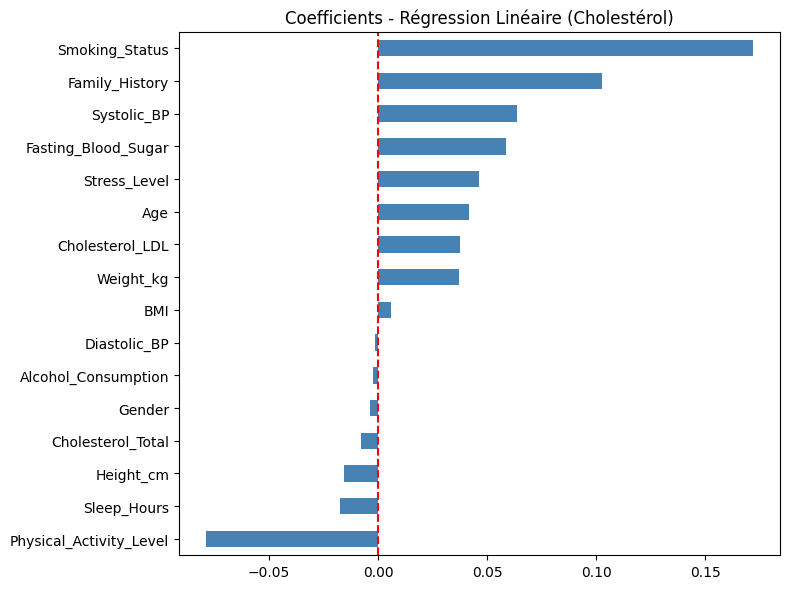

In [51]:
# Récupérer les coefficients du modèle entraîné
coef_chol = pd.Series(LM_Chol.coef_, index=X_chol.columns)

# Trier et tracer
coef_chol.sort_values().plot(kind='barh', figsize=(8, 6), color='steelblue')

plt.title("Coefficients - Régression Linéaire (Cholestérol)")
plt.axvline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

Les coefficients du modèle linéaire révèlent que `Smoking_Status` et `Family_History` 
sont les variables les plus influentes sur `Cholesterol_LDL`, avec les coefficients 
positifs les plus élevés — fumer et avoir des antécédents familiaux augmentent donc 
significativement le taux de mauvais cholestérol. `Systolic_BP`, `Fasting_Blood_Sugar`, 
`Stress_Level` et `Age` contribuent également positivement mais de façon plus modérée.

À l'inverse, `Physical_Activity_Level` a le coefficient négatif le plus fort — 
l'activité physique réduit le taux de LDL, ce qui est **cohérent médicalement**.

On note que `Diastolic_BP`, `Alcohol_Consumption` et `Gender` ont des coefficients 
quasi nuls, suggérant une faible contribution à la prédiction de `Cholesterol_LDL`.

Ces résultats sont **cohérents avec l'analyse exploratoire** réalisée précédemment.

##### Pénalisation Lasso L1
On applique maintenant une pénalisation **Lasso (L1)** sur la régression linéaire.
L'objectif est double : réduire le sur-apprentissage et effectuer une **sélection 
automatique de variables** en poussant certains coefficients exactement à zéro.

Dans un premier temps on utilise l'**alpha par défaut** (alpha=1) pour observer 
l'effet de la pénalisation, puis on optimisera alpha par validation croisée.

MSE = 0.2432575625
R2  = -0.003409475273377094

Variables éliminées  : 16
Variables conservées : 0


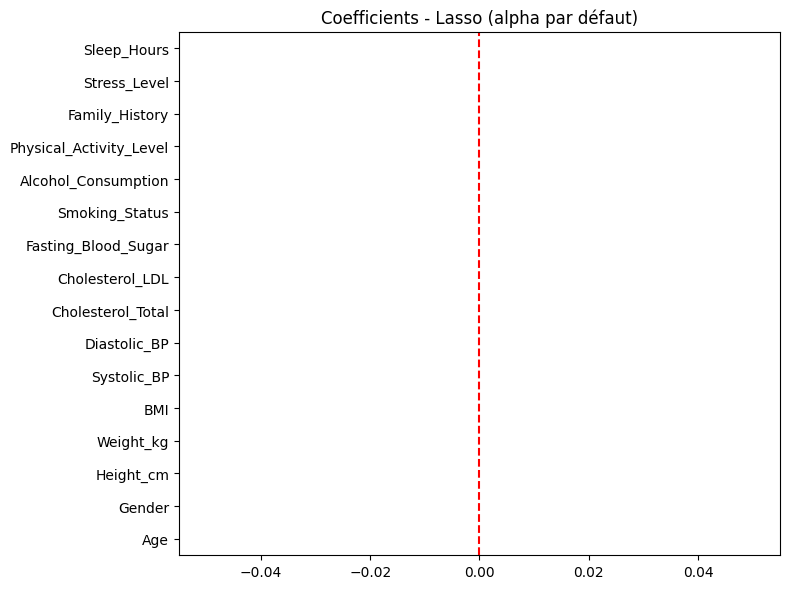

In [53]:
from sklearn import linear_model

# ── Lasso avec alpha par défaut (alpha=1) ─────────────────────
regLasso_chol = linear_model.Lasso()
regLasso_chol.fit(Xr_train_chol, y_train_chol)

# ── Prédictions ───────────────────────────────────────────────
prev_chol = regLasso_chol.predict(Xr_test_chol)

# ── Performances ──────────────────────────────────────────────
print("MSE =", mean_squared_error(y_test_chol, prev_chol))
print("R2  =", r2_score(y_test_chol, prev_chol))

# ── Coefficients ──────────────────────────────────────────────
coef_lasso_chol = pd.Series(regLasso_chol.coef_, index=X_chol.columns)
print(f"\nVariables éliminées  : {sum(coef_lasso_chol == 0)}")
print(f"Variables conservées : {sum(coef_lasso_chol != 0)}")

coef_lasso_chol.sort_values().plot(kind='barh', figsize=(8, 6), color='salmon')
plt.title("Coefficients - Lasso (alpha par défaut)")
plt.axvline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

Avec l'alpha par défaut (alpha=1), la pénalisation est **beaucoup trop forte** — 
tous les coefficients sont poussés exactement à zéro. Le modèle prédit simplement 
la moyenne de `Cholesterol_LDL` pour chaque patient, ce qui est équivalent à 
n'avoir aucun modèle. Cela illustre l'importance du choix de l'hyperparamètre alpha — 
un alpha trop grand détruit toute l'information. On va donc optimiser alpha par 
validation croisée dans l'étape suivante.

In [54]:
from sklearn.model_selection import GridSearchCV

# ── Grille de valeurs alpha ───────────────────────────────────
param = [{"alpha": [0.0001, 0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1]}]

# ── Optimisation par validation croisée ──────────────────────
regLasso_opt = GridSearchCV(linear_model.Lasso(max_iter=10000),
                             param, cv=10, n_jobs=-1)
regLassoOpt_chol = regLasso_opt.fit(Xr_train_chol, y_train_chol)

print("Meilleur R2    =", round(regLassoOpt_chol.best_score_, 4))
print("Meilleur alpha =", regLassoOpt_chol.best_params_)

# ── Prédictions ───────────────────────────────────────────────
prev_chol_opt = regLassoOpt_chol.predict(Xr_test_chol)

print("MSE =", round(mean_squared_error(y_test_chol, prev_chol_opt), 4))
print("R2  =", round(r2_score(y_test_chol, prev_chol_opt), 4))

Meilleur R2    = 0.2719
Meilleur alpha = {'alpha': 0.001}
MSE = 0.174
R2  = 0.2821


Le Lasso optimisé par validation croisée trouve un **alpha optimal = 0.001** — 
une pénalisation très faible, ce qui explique pourquoi les performances sont 
quasiment identiques au modèle linéaire simple :

| Modèle | MSE Test | R² Test |
|---|---|---|
| Régression linéaire (MCO) | 0.1740 | 0.2821 |
| Lasso (alpha=0.001) | 0.1740 | 0.2821 |

Le Lasso n'apporte **aucune amélioration** par rapport au modèle de base — 
toutes les variables sont conservées car elles contribuent toutes à la prédiction 
de `Cholesterol_LDL`. 

Ce plafond à **R² ≈ 0.28** confirme que la relation entre les variables 
explicatives et le LDL n'est pas linéaire. Les modèles non linéaires 
(SVM, Random Forest, Boosting) devraient apporter une amélioration significative.

Variables éliminées  : 2
Variables conservées : 14


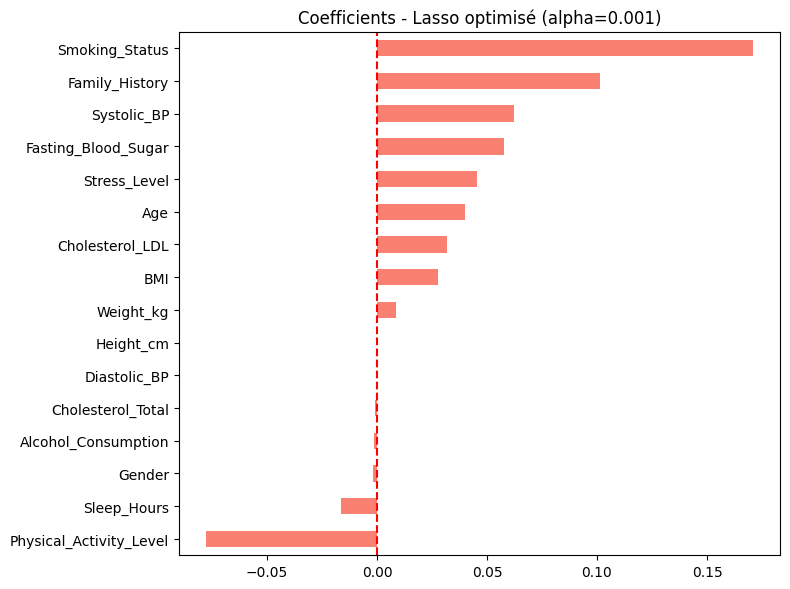

In [55]:
# ── Ré-estimation avec alpha optimal pour afficher les coefficients ──
regLasso_final = linear_model.Lasso(
    alpha=regLassoOpt_chol.best_params_['alpha'], 
    max_iter=10000)
regLasso_final.fit(Xr_train_chol, y_train_chol)

coef_lasso_opt = pd.Series(regLasso_final.coef_, index=X_chol.columns)
print(f"Variables éliminées  : {sum(coef_lasso_opt == 0)}")
print(f"Variables conservées : {sum(coef_lasso_opt != 0)}")

coef_lasso_opt.sort_values().plot(kind='barh', figsize=(8, 6), color='salmon')
plt.title(f"Coefficients - Lasso optimisé (alpha={regLassoOpt_chol.best_params_['alpha']})")
plt.axvline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

Avec l'alpha optimal (0.001), le Lasso élimine **2 variables** (`Height_cm` et 
`Diastolic_BP`) et conserve 14 variables sur 16. Ces deux variables avaient déjà 
des coefficients quasi nuls dans le modèle linéaire simple, confirmant leur faible 
contribution à la prédiction de `Cholesterol_LDL`.

TypeError: Categorical is not ordered for operation min
you can use .as_ordered() to change the Categorical to an ordered one


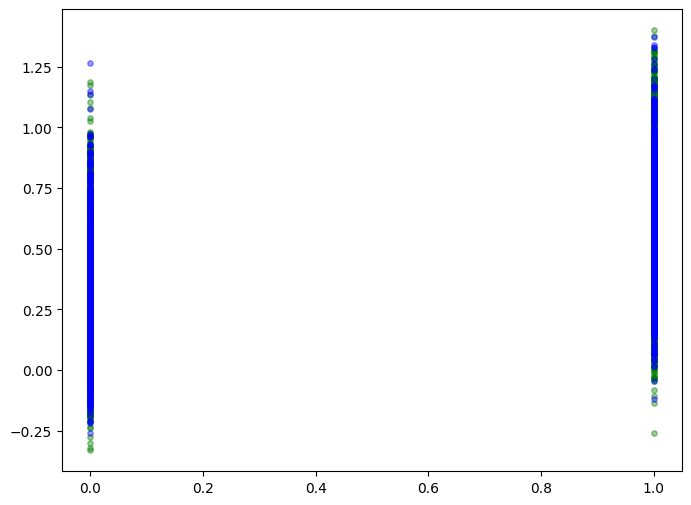

In [57]:
# ── Prédictions vs Valeurs réelles ───────────────────────────
plt.figure(figsize=(8, 6))

# Points train en vert
plt.scatter(y_train_chol, 
            LM_Chol.predict(Xr_train_chol), 
            alpha=0.4, color='green', s=15, label='Train')

# Points test en bleu
plt.scatter(y_test_chol, 
            y_pred_chol_test, 
            alpha=0.4, color='blue', s=15, label='Test')

# Ligne idéale
min_val = min(y_test_chol.min(), y_pred_chol_test.min())
max_val = max(y_test_chol.max(), y_pred_chol_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 
         color='red', lw=2, label='Prédiction parfaite')

plt.xlabel("Valeurs réelles (Cholesterol_LDL)")
plt.ylabel("Valeurs prédites")
plt.title("Prédictions vs Valeurs réelles - Régression Linéaire")
plt.legend()
plt.tight_layout()
plt.show()